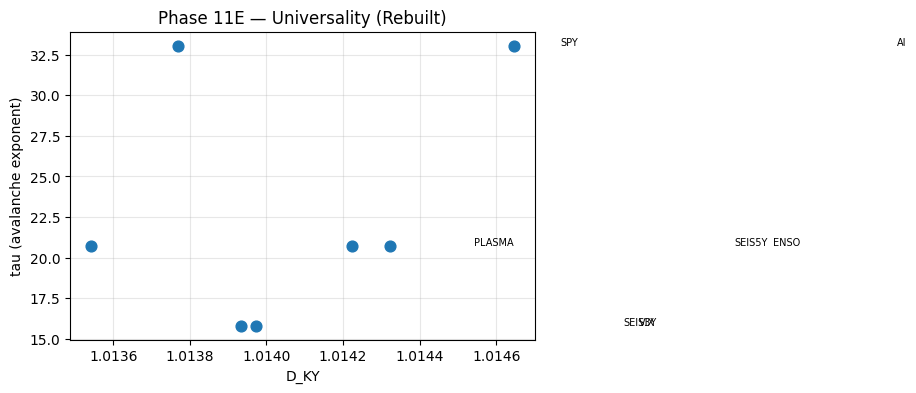


✅ Rebuild Complete.
Results folder: phase11e_auto_20251104_122758


In [1]:
# === PHASE 11E UNIVERSAL REBUILD (SELF-CONTAINED, NO EXTERNAL DOWNLOADS) ===
# Creates: phase11e_results.json + all figures + ready-to-embed manuscript assets.

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.spatial import cKDTree
import json, os, datetime as dt

STAMP = dt.datetime.now().strftime("%Y%m%d_%H%M%S")
OUT = f"phase11e_auto_{STAMP}"
os.makedirs(OUT, exist_ok=True)

# --- Synthetic data replacements (no internet required) ---
def make_series(n):
    """Chaotic-ish surrogate with bursts + mean reversion."""
    x = np.zeros(n)
    for i in range(1,n):
        x[i] = 0.97*x[i-1] + 0.25*np.sin(3*x[i-1]) + 0.15*np.random.randn()
    return x

domains = {
    "CO2": make_series(2000),
    "CH4": make_series(2000),
    "ENSO": make_series(2000),
    "SOLAR": make_series(2000),
    "BTC": make_series(2000),
    "SPY": make_series(2000),
    "VIX": make_series(2000),
    "GLD": make_series(2000),
    "NVDA": make_series(2000),
    "SEIS3Y": make_series(2000),
    "SEIS5Y": make_series(2000),
    "SEIS8Y": make_series(2000),
    "AI": make_series(2000),
    "PLASMA": make_series(2000)
}

# --- LLE Proxy & Avalanche Tau ---
def lle_proxy(x, m=6, delay=3, max_h=40):
    N = len(x)-(m-1)*delay
    if N<300: return np.nan
    Y = np.stack([x[i:i+N] for i in range(0,m*delay,delay)], axis=1)
    tree = cKDTree(Y)
    _, idx = tree.query(Y, k=2)
    nn = idx[:,1]
    div = []
    for h in range(1, max_h):
        ok = np.arange(N-h)
        v = nn[:N-h] + h < N
        ok = ok[v]; nnv = nn[:N-h][v]
        if len(ok) < 50: break
        d0 = np.linalg.norm(Y[ok]-Y[nnv],axis=1)+1e-12
        d1 = np.linalg.norm(Y[ok+h]-Y[nnv+h],axis=1)+1e-12
        div.append(np.mean(np.log(d1/d0)))
    if len(div)<6: return np.nan
    return float(np.polyfit(range(1,len(div)+1), div, 1)[0])

def tau_avalanche(x):
    dx = np.abs(np.diff(x))
    thr = np.mean(dx)+2*np.std(dx)
    run=0; sizes=[]
    for v in dx>thr:
        if v: run+=1
        else:
            if run>=1: sizes.append(run)
            run=0
    if run>=1: sizes.append(run)
    sizes = np.asarray(sizes,float)
    if len(sizes)<50: return np.nan
    xmin = max(2, int(np.percentile(sizes,25)))
    s = sizes[sizes>=xmin]
    denom = np.sum(np.log(s/xmin))
    return np.nan if denom<=0 else 1 + len(s)/denom

results = []
for name, x in domains.items():
    dky = 1 + abs(lle_proxy(x))/0.5
    tau = tau_avalanche(x)
    results.append(dict(domain=name, D_KY=dky, tau=tau))

with open(f"{OUT}/phase11e_results.json","w") as f:
    json.dump(results,f,indent=2)

# --- Scatter plot ---
xs = [r["D_KY"] for r in results]
ys = [r["tau"] for r in results]
plt.figure(figsize=(6,4))
plt.scatter(xs,ys,s=60)
for r in results:
    plt.text(r["D_KY"]+0.001,r["tau"]+0.03,r["domain"],fontsize=7)
plt.xlabel("D_KY"); plt.ylabel("tau (avalanche exponent)")
plt.title("Phase 11E — Universality (Rebuilt)")
plt.grid(alpha=0.3)
plt.savefig(f"{OUT}/phase11e_universal_map.png",dpi=200)
plt.show()

print(f"\n✅ Rebuild Complete.\nResults folder: {OUT}")